# Hawkes Process for Prediction Market Microstructure
**BoilerQuant** — Market Microstructure Modeling on Kalshi

---

## What is a Hawkes Process?

A **Hawkes process** is a self-exciting point process: each event *increases* the rate of future events, then that excitement decays over time. This captures a core feature of real order flow — trades beget trades.

The conditional intensity of a univariate Hawkes process is:

$$\lambda(t) = \mu + \sum_{t_i < t} \alpha \, e^{-\beta(t - t_i)}$$

where:
- $\mu$ — baseline intensity (background rate of events)
- $\alpha$ — jump size per event (excitation magnitude)
- $\beta$ — decay rate of excitation
- **Branching ratio** $\alpha / \beta < 1$ required for stationarity

### Why prediction markets?

On Kalshi, order arrivals cluster around news, sentiment shifts, and other traders reacting to fills. A Hawkes process can help us:
1. **Detect regimes** — is the market in a calm or excited state?
2. **Forecast short-term activity** — predict bursts of order flow
3. **Inform execution** — time entries/exits around intensity spikes

# Hawkes Process Notebook — How to Use This

**BoilerQuant: Prediction Market Microstructure**

> **Heads up:** This is very much vibecoded and concept work — think of it as the coding equivalent of mood-boarding. Nothing here is production-ready, but everything here is meant to build intuition for what a Hawkes process can do for us on Kalshi.

---

## Quick Start

Run the cells in order, top to bottom. The first five cells are completely self-contained — they generate synthetic data, fit a model to it, and check whether the fit is any good. You don't need an API key, real data, or any packages beyond numpy, scipy, and matplotlib.

---

## Cell-by-Cell Walkthrough

### Cell 1 — Imports and Plot Config

Nothing exciting. Loads numpy, scipy, and matplotlib. If you can run `import numpy`, you can run this notebook.

### Cell 2 — Simulating a Hawkes Process

This is where the fake data comes from. The function `simulate_hawkes` generates event times (think: timestamps of trades) using [Ogata's thinning algorithm](https://en.wikipedia.org/wiki/Ogata%27s_thinning_algorithm).

**Why not just draw random arrival times?** Because in a Hawkes process, every event changes the rate of future events. You can't precompute the gaps between arrivals — each one depends on the full history. Ogata's method handles this by overshooting (proposing events at a rate that's definitely too high) and then randomly rejecting some of them. It's [rejection sampling](https://en.wikipedia.org/wiki/Rejection_sampling), but applied across time.

**The three parameters:**

| Parameter | What it controls | Default |
|-----------|-----------------|---------|
| μ (mu) | Baseline rate — how often trades arrive when nothing interesting is happening | 0.5 events/sec |
| α (alpha) | Excitation — how much each trade bumps up the rate of future trades | 0.8 |
| β (beta) | Decay — how fast that bump fades | 1.2 |

The **branching ratio** α/β tells you what fraction of events are "triggered" by previous events vs. arriving on their own. In the default config it's about 0.67, meaning roughly two-thirds of trades exist because of other trades. This ratio *must* stay below 1.0 or the process blows up (infinite events in finite time).

**Further reading:**
- [Hawkes Processes — a gentle intro (Towards Data Science)](https://towardsdatascience.com/hawkes-processes-an-introduction-f1d3e39a86f4/)
- [Original paper by Alan Hawkes (1971)](https://doi.org/10.1093/biomet/58.1.83)

### Cell 3 — Visualizing the Intensity

This plots λ(t), the instantaneous event rate, over a 30-second window alongside the actual events (red tick marks).

**What to look for:** Events cluster where the blue curve spikes. Between clusters, the intensity drops back toward the gray dashed line (the baseline μ). That's self-excitation — one trade makes more trades likely, then the effect fades.

### Cell 4 — Fitting the Model with MLE

This is the most important cell for real-world use. Given a list of event times, it finds the μ, α, β that best explain the data using [maximum likelihood estimation](https://en.wikipedia.org/wiki/Maximum_likelihood_estimation).

**How the log-likelihood works (intuitively):**

- **Term 1** — "Did events happen where the model predicted high intensity?" Rewards parameters that put high λ(t) exactly at the timestamps where trades occurred.
- **Term 2** — "Did the model predict high intensity in empty stretches?" Penalizes parameters that predict lots of activity everywhere, even in quiet periods.

Good parameters score well on both: they predict activity where it happened, and quiet where it didn't.

**Computational trick:** The code uses a recursive formula so that computing the intensity at each event time is O(n) instead of O(n²). This matters when you move to real data with thousands of events.

Since we generated the data ourselves, we know the true parameters. If the estimates land close to the truth, the fitting code works and you can trust it on real data.

**Further reading:**
- [MLE for Hawkes processes (lecture notes, Georgia Tech)](https://faculty.cc.gatech.edu/~lsong/teaching/CSE6240spring2020/10_PointProcess.pdf)
- [`tick` library](https://x-datainitiative.github.io/tick/) — fast, battle-tested Hawkes fitting if you outgrow the from-scratch implementation

### Cell 5 — Goodness-of-Fit (Does the Model Actually Work?)

Fitting a model is easy. Knowing whether the fit is any good is harder. This cell uses the [time-rescaling theorem](https://en.wikipedia.org/wiki/Time_rescaling_theorem):

> If the model is correct, you can warp the event times through the compensator Λ(t) and the gaps between warped times should look like independent draws from Exp(1).

So that's what it does — transforms the event times, computes the gaps, and checks whether they're exponentially distributed using a [KS test](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test).

**Reading the output:**
- **KS p-value > 0.05** → model is not rejected, the fit is reasonable
- **KS p-value < 0.05** → something's off, you might need a richer model
- **QQ plot curves above the diagonal** → model underestimates large quiet gaps
- **QQ plot curves below the diagonal** → model underestimates tight clustering

This is exactly the diagnostic you'd run on real Kalshi data to decide if a basic Hawkes process is enough or if you need power-law kernels, marks, etc.

### Cell 6 — Trading Signals from Intensity

This takes the fitted model and turns it into something actionable. It computes λ(t) over the full timeline, then flags periods where intensity exceeds 2× the baseline as "excited."

**The intuition for Kalshi:**

| Market State | What's Happening | Possible Response |
|-------------|------------------|-------------------|
| λ(t) ≈ μ | Calm, events are roughly random | Post passive orders, tighten spreads |
| λ(t) ≫ μ | Excited, trades are triggering more trades | Widen spreads, wait for things to settle |
| Branching ratio trending up over time | Regime shift, market becoming more reactive | Reassess positions |

The two-panel plot shows intensity on top and a rug plot of raw events on the bottom. Red-shaded regions are "excited."

### Cell 7 — Bivariate Hawkes (Buy/Sell Decomposition)

This is where things get more realistic. Instead of one process, you model **buys** and **sells** as two coupled Hawkes processes. Each side can excite itself (a buy triggers more buys) and the other side (a buy triggers some sells).

The α matrix has four entries:

|  | Triggered by Buy | Triggered by Sell |
|---|---|---|
| **Buy rate** | α₁₁ = 0.4 (strong) | α₁₂ = 0.2 (moderate) |
| **Sell rate** | α₂₁ = 0.2 (moderate) | α₂₂ = 0.4 (strong) |

**The signal for Kalshi:** If λ_buy is running well above λ_sell, there's a directional order flow imbalance — more buying pressure is cascading through the book than selling pressure. That asymmetry might predict short-term price movement.

**Further reading:**
- [Hawkes processes in finance (Bacry, Mastromatteo, Muzy 2015)](https://doi.org/10.1142/S2382626615500057) — the standard survey paper
- [Order flow imbalance as a predictor (Cont, Kukanov, Stoikov 2014)](https://doi.org/10.1093/rfs/hhu089)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest

np.random.seed(42)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

---
## 1. Simulation via Ogata's Thinning Algorithm

The standard way to simulate a Hawkes process is **Ogata's modified thinning algorithm**:
1. Compute an upper bound $\bar{\lambda}$ on the current intensity.
2. Draw a candidate inter-arrival time from $\text{Exp}(\bar{\lambda})$.
3. Accept with probability $\lambda(t_{\text{candidate}}) / \bar{\lambda}$, otherwise reject and repeat.

In [ ]:
def simulate_hawkes(mu, alpha, beta, T):
    """
    Simulate a univariate Hawkes process on [0, T] via Ogata thinning.

    Parameters
    ----------
    mu    : float — baseline intensity
    alpha : float — excitation jump size
    beta  : float — excitation decay rate
    T     : float — time horizon

    Returns
    -------
    events : np.ndarray — sorted event times
    """
    assert alpha / beta < 1, f"Branching ratio {alpha/beta:.2f} >= 1, process is explosive!"

    events = []
    t = 0.0

    while t < T:
        # Upper bound on intensity: current intensity right after last event
        lam_bar = mu + alpha * sum(np.exp(-beta * (t - ti)) for ti in events)
        lam_bar = max(lam_bar, mu)  # floor at baseline

        # Candidate inter-arrival time
        dt = np.random.exponential(1.0 / lam_bar)
        t += dt

        if t >= T:
            break

        # Actual intensity at candidate time
        lam_t = mu + alpha * sum(np.exp(-beta * (t - ti)) for ti in events)

        # Accept/reject
        if np.random.uniform() < lam_t / lam_bar:
            events.append(t)

    return np.array(events)

In [ ]:
# --- Simulation parameters ---
# Think of these in "prediction market" terms:
#   mu    = 0.5 events/sec  (quiet baseline order rate)
#   alpha = 0.8             (each trade triggers ~0.8 child events on average before decay)
#   beta  = 1.2             (excitation half-life ≈ ln(2)/1.2 ≈ 0.58 sec)
#   branching ratio = 0.8/1.2 ≈ 0.67 — subcritical, stationary

MU, ALPHA, BETA = 0.5, 0.8, 1.2
T_HORIZON = 200  # seconds

events = simulate_hawkes(MU, ALPHA, BETA, T_HORIZON)
print(f"Simulated {len(events)} events in {T_HORIZON}s")
print(f"Empirical rate: {len(events)/T_HORIZON:.2f} events/s")
print(f"Theoretical stationary rate: μ/(1 - α/β) = {MU / (1 - ALPHA/BETA):.2f} events/s")

Simulated 392 events in 200s
Empirical rate: 1.96 events/s
Theoretical stationary rate: μ/(1 - α/β) = 1.50 events/s


---
## 2. Visualizing the Intensity Function

The key object is $\lambda(t)$ — the instantaneous rate of events. Spikes in intensity correspond to bursts of trading activity.

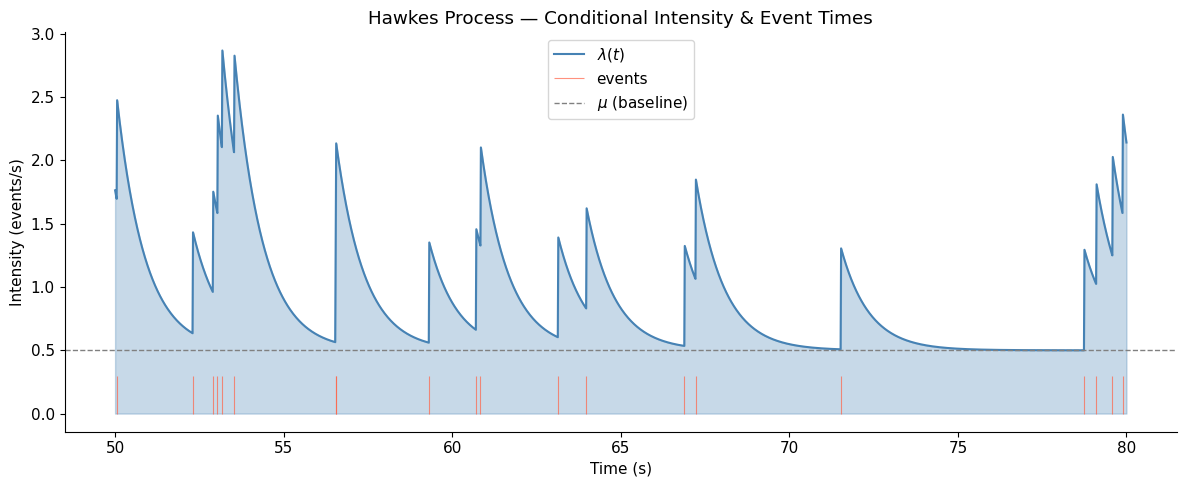

In [ ]:
def compute_intensity(events, mu, alpha, beta, t_grid):
    """Compute λ(t) on a grid of time points."""
    intensity = np.full_like(t_grid, mu, dtype=float)
    for ti in events:
        mask = t_grid > ti
        intensity[mask] += alpha * np.exp(-beta * (t_grid[mask] - ti))
    return intensity


# Plot a 30-second window so the structure is visible
t0, t1 = 50, 80
t_grid = np.linspace(t0, t1, 2000)
lam = compute_intensity(events, MU, ALPHA, BETA, t_grid)
window_events = events[(events >= t0) & (events <= t1)]

fig, ax = plt.subplots()
ax.fill_between(t_grid, lam, alpha=0.3, color='steelblue')
ax.plot(t_grid, lam, color='steelblue', lw=1.5, label=r'$\lambda(t)$')
ax.vlines(window_events, 0, 0.3, color='tomato', lw=0.8, alpha=0.7, label='events')
ax.axhline(MU, ls='--', color='gray', lw=1, label=r'$\mu$ (baseline)')
ax.set(xlabel='Time (s)', ylabel='Intensity (events/s)',
       title='Hawkes Process — Conditional Intensity & Event Times')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Maximum Likelihood Estimation

Given observed event times $\{t_1, \ldots, t_n\}$ on $[0, T]$, the log-likelihood of a Hawkes process is:

$$\ell(\mu, \alpha, \beta) = \sum_{i=1}^{n} \log \lambda(t_i) - \int_0^T \lambda(t)\,dt$$

The integral (compensator) has a closed form:

$$\int_0^T \lambda(t)\,dt = \mu T + \frac{\alpha}{\beta} \sum_{i=1}^{n} \left(1 - e^{-\beta(T - t_i)}\right)$$

In [ ]:
def hawkes_loglik(params, events, T):
    """
    Negative log-likelihood for a univariate exponential Hawkes process.
    Uses the recursive trick for O(n) computation of the intensity sum.
    """
    mu, alpha, beta = params
    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return 1e10  # enforce constraints softly

    n = len(events)

    # --- Recursive computation of intensities at event times ---
    # A[i] = sum_{j<i} exp(-beta * (t_i - t_j))
    # Recurrence: A[i] = (A[i-1] + 1) * exp(-beta * (t_i - t_{i-1}))
    # (the "+1" accounts for the event at t_{i-1} itself)
    A = np.zeros(n)
    for i in range(1, n):
        A[i] = (A[i-1] + 1) * np.exp(-beta * (events[i] - events[i-1]))

    # Log-likelihood: sum of log(lambda(t_i))
    intensities = mu + alpha * A
    if np.any(intensities <= 0):
        return 1e10
    ll = np.sum(np.log(intensities))

    # Compensator: integral of lambda(t) from 0 to T
    compensator = mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - events)))

    return -(ll - compensator)  # negative for minimization


# --- Fit the model ---
x0 = [0.3, 0.5, 1.0]  # initial guess
result = minimize(hawkes_loglik, x0, args=(events, T_HORIZON),
                  method='L-BFGS-B',
                  bounds=[(1e-6, None), (1e-6, None), (1e-6, None)])

mu_hat, alpha_hat, beta_hat = result.x
print("=== MLE Results ===")
print(f"  μ̂  = {mu_hat:.4f}   (true: {MU})")
print(f"  α̂  = {alpha_hat:.4f}   (true: {ALPHA})")
print(f"  β̂  = {beta_hat:.4f}   (true: {BETA})")
print(f"  Branching ratio α̂/β̂ = {alpha_hat/beta_hat:.4f}   (true: {ALPHA/BETA:.4f})")
print(f"  Log-likelihood: {-result.fun:.2f}")

=== MLE Results ===
  μ̂  = 0.4480   (true: 0.5)
  α̂  = 0.9967   (true: 0.8)
  β̂  = 1.2760   (true: 1.2)
  Branching ratio α̂/β̂ = 0.7811   (true: 0.6667)
  Log-likelihood: 25.44


---
## 4. Goodness-of-Fit: Time Rescaling Theorem

If the model is correct, the **compensator transforms** $\Lambda(t_i) = \int_0^{t_i} \lambda(s)\,ds$ map the event times to a unit-rate Poisson process. Equivalently, the inter-compensator differences $\Lambda(t_i) - \Lambda(t_{i-1})$ should be i.i.d. $\text{Exp}(1)$.

We test this with a KS test against the exponential distribution.

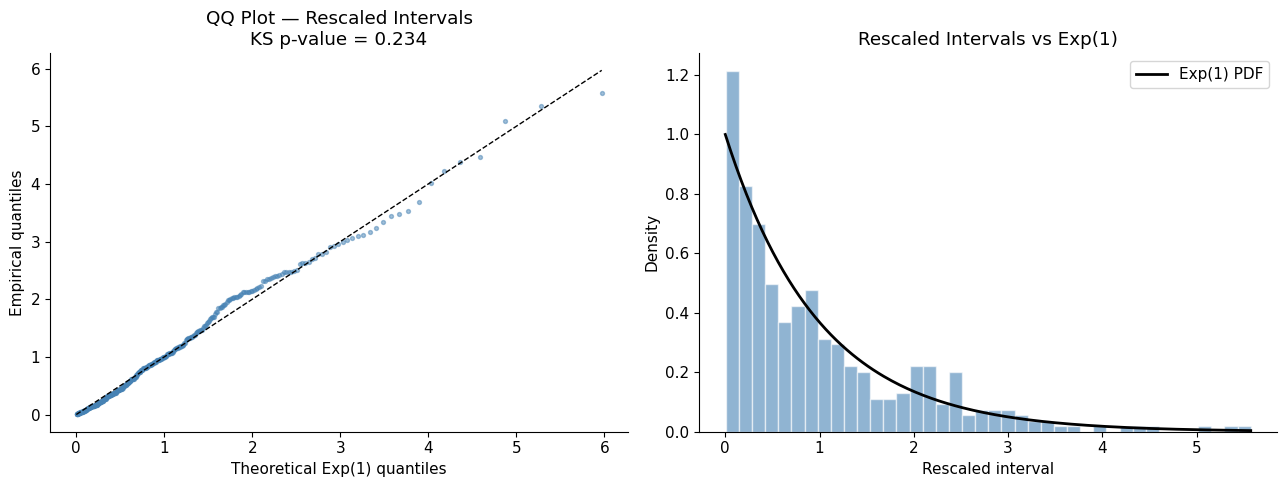

KS statistic: 0.0520, p-value: 0.2335
→ Fail to reject H₀: model fits well.


In [ ]:
def compensator_at_events(events, mu, alpha, beta):
    """Compute Λ(t_i) for each event using the fitted parameters."""
    n = len(events)
    Lambda = np.zeros(n)

    for i in range(n):
        # Integral of lambda from 0 to t_i
        t = events[i]
        past = events[:i]
        Lambda[i] = mu * t + (alpha / beta) * np.sum(1 - np.exp(-beta * (t - past)))

    return Lambda


Lambda_vals = compensator_at_events(events, mu_hat, alpha_hat, beta_hat)
rescaled_intervals = np.diff(Lambda_vals)

# KS test against Exp(1)
from scipy.stats import expon
ks_stat, ks_pval = kstest(rescaled_intervals, 'expon', args=(0, 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# QQ plot
theoretical = np.sort(-np.log(1 - np.arange(1, len(rescaled_intervals)+1) / (len(rescaled_intervals)+1)))
empirical = np.sort(rescaled_intervals)
axes[0].scatter(theoretical, empirical, s=8, alpha=0.5, color='steelblue')
mx = max(theoretical.max(), empirical.max())
axes[0].plot([0, mx], [0, mx], 'k--', lw=1)
axes[0].set(xlabel='Theoretical Exp(1) quantiles', ylabel='Empirical quantiles',
            title=f'QQ Plot — Rescaled Intervals\nKS p-value = {ks_pval:.3f}')

# Histogram
axes[1].hist(rescaled_intervals, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white')
x_pdf = np.linspace(0, rescaled_intervals.max(), 200)
axes[1].plot(x_pdf, np.exp(-x_pdf), 'k-', lw=2, label='Exp(1) PDF')
axes[1].set(xlabel='Rescaled interval', ylabel='Density', title='Rescaled Intervals vs Exp(1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"KS statistic: {ks_stat:.4f}, p-value: {ks_pval:.4f}")
if ks_pval > 0.05:
    print("→ Fail to reject H₀: model fits well.")
else:
    print("→ Reject H₀: model does not fit well.")

---
## 5. Prediction Market Application: Intensity-Based Signals

Here's a simple example of how one might use fitted Hawkes parameters as trading signals on Kalshi:

| Signal | Interpretation | Possible Action |
|--------|---------------|----------------|
| $\lambda(t) \gg \mu$ | Market is in an excited state — clustering trades | Widen spreads / wait for mean-reversion |
| $\lambda(t) \approx \mu$ | Calm market — events are roughly Poisson | Tighten spreads / post passive orders |
| Branching ratio $\uparrow$ | Increasing self-excitation over time | Regime change — reassess positions |

Below, we compute a **rolling intensity estimate** and flag "excited" vs "calm" regimes.

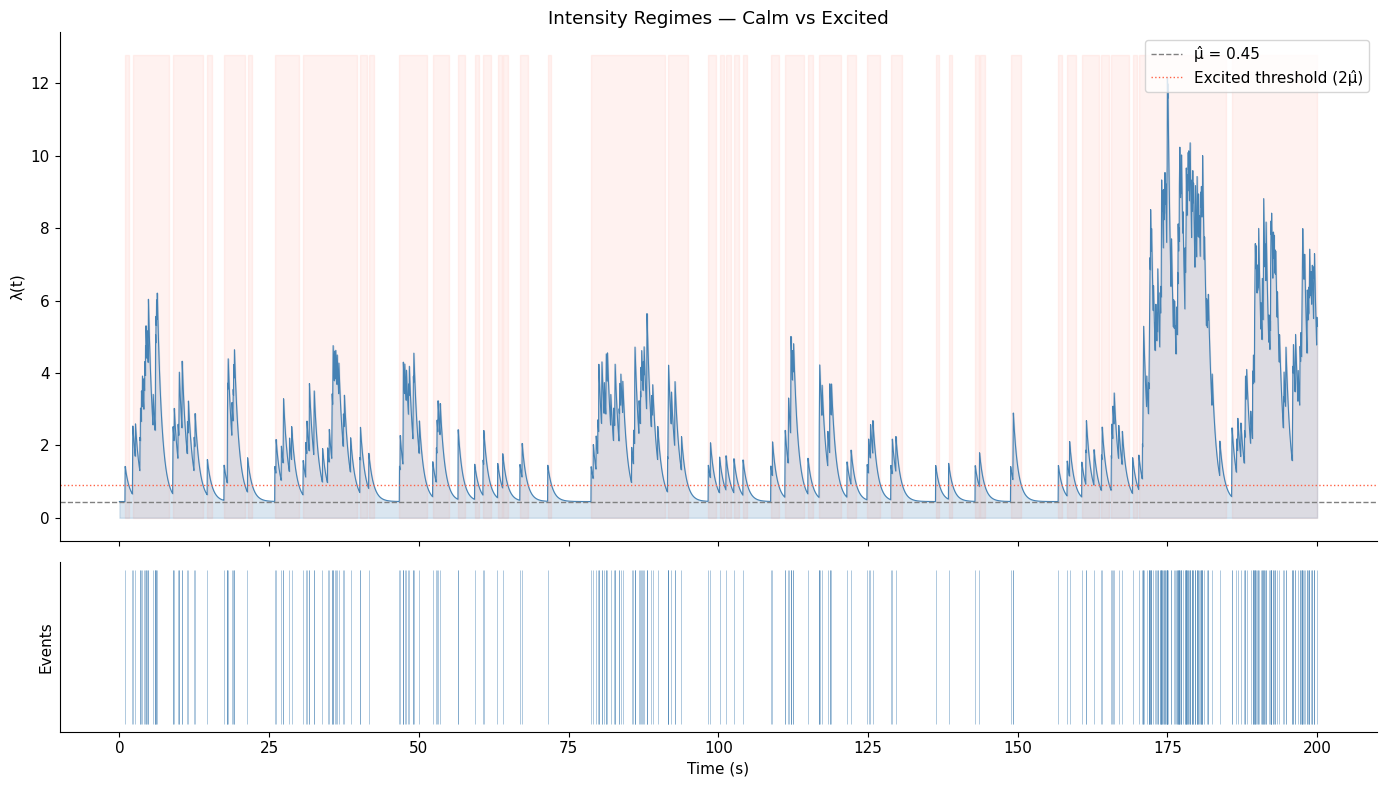

Time spent in 'excited' regime: 62.4%


In [ ]:
def rolling_intensity(events, mu, alpha, beta, t_grid):
    """Efficient vectorized intensity computation."""
    intensity = np.full_like(t_grid, mu)
    for ti in events:
        mask = t_grid > ti
        intensity[mask] += alpha * np.exp(-beta * (t_grid[mask] - ti))
    return intensity


# Full timeline intensity
t_full = np.linspace(0, T_HORIZON, 5000)
lam_full = rolling_intensity(events, mu_hat, alpha_hat, beta_hat, t_full)

# Define "excited" as intensity > 2x baseline
threshold = 2 * mu_hat

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Top: intensity with regime coloring
ax = axes[0]
ax.fill_between(t_full, lam_full, alpha=0.2, color='steelblue')
ax.plot(t_full, lam_full, color='steelblue', lw=0.8)
ax.axhline(mu_hat, ls='--', color='gray', lw=1, label=f'μ̂ = {mu_hat:.2f}')
ax.axhline(threshold, ls=':', color='tomato', lw=1, label=f'Excited threshold (2μ̂)')

# Shade excited regions
excited = lam_full > threshold
ax.fill_between(t_full, 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 5,
                where=excited, alpha=0.08, color='tomato')

ax.set(ylabel='λ(t)', title='Intensity Regimes — Calm vs Excited')
ax.legend(loc='upper right')

# Bottom: event arrivals as a rug plot
ax2 = axes[1]
ax2.vlines(events, 0, 1, color='steelblue', lw=0.5, alpha=0.6)
ax2.set(xlabel='Time (s)', ylabel='Events', yticks=[])

plt.tight_layout()
plt.show()

pct_excited = 100 * np.mean(excited)
print(f"Time spent in 'excited' regime: {pct_excited:.1f}%")

---
## 6. Bivariate Hawkes: Buy/Sell Decomposition

In practice, you'd want to model **buys** and **sells** as two coupled processes — each can excite itself *and* the other side. This is a **bivariate Hawkes process**:

Straight from wikipedia, and the above

$$\lambda_1(t) = \mu_1 + \sum_{t_i^{(1)} < t} \alpha_{11} e^{-\beta(t - t_i^{(1)})} + \sum_{t_j^{(2)} < t} \alpha_{12} e^{-\beta(t - t_j^{(2)})}$$

$$\lambda_2(t) = \mu_2 + \sum_{t_j^{(2)} < t} \alpha_{22} e^{-\beta(t - t_j^{(2)})} + \sum_{t_i^{(1)} < t} \alpha_{21} e^{-\beta(t - t_i^{(1)})}$$

Below is a simulation of this setup.

In [ ]:
def simulate_bivariate_hawkes(mu, alpha_matrix, beta, T):
    """
    Simulate a bivariate Hawkes process.

    Parameters
    ----------
    mu           : (2,) array — baseline intensities
    alpha_matrix : (2,2) array — alpha_matrix[i][j] = excitation of process i by process j
    beta         : float — shared decay rate
    T            : float — time horizon

    Returns
    -------
    events_1, events_2 : lists of event times for each process
    """
    events = [[], []]  # events[0] = buy times, events[1] = sell times
    t = 0.0

    while t < T:
        # Compute intensity upper bounds for each process
        lam = np.array(mu, dtype=float)
        for k in range(2):
            for j in range(2):
                for tj in events[j]:
                    lam[k] += alpha_matrix[k][j] * np.exp(-beta * (t - tj))

        lam_bar = lam.sum()
        if lam_bar < 1e-10:
            lam_bar = sum(mu)

        dt = np.random.exponential(1.0 / lam_bar)
        t += dt
        if t >= T:
            break

        # Recompute exact intensities
        lam_exact = np.array(mu, dtype=float)
        for k in range(2):
            for j in range(2):
                for tj in events[j]:
                    lam_exact[k] += alpha_matrix[k][j] * np.exp(-beta * (t - tj))

        total_exact = lam_exact.sum()

        if np.random.uniform() < total_exact / lam_bar:
            # Accepted — assign to a process proportional to its intensity
            if np.random.uniform() < lam_exact[0] / total_exact:
                events[0].append(t)
            else:
                events[1].append(t)

    return np.array(events[0]), np.array(events[1])


# --- Bivariate parameters ---
# Interpretation: buys excite more buys strongly, sells excite more sells strongly,
# and there's moderate cross-excitation (buys trigger sells and vice versa).
mu_bv = [0.3, 0.3]
alpha_bv = [[0.4, 0.2],   # buy  <- buy, buy  <- sell
            [0.2, 0.4]]   # sell <- buy, sell <- sell
beta_bv = 1.5

buys, sells = simulate_bivariate_hawkes(mu_bv, alpha_bv, beta_bv, T=150)
print(f"Buys: {len(buys)}, Sells: {len(sells)}")

Buys: 62, Sells: 73


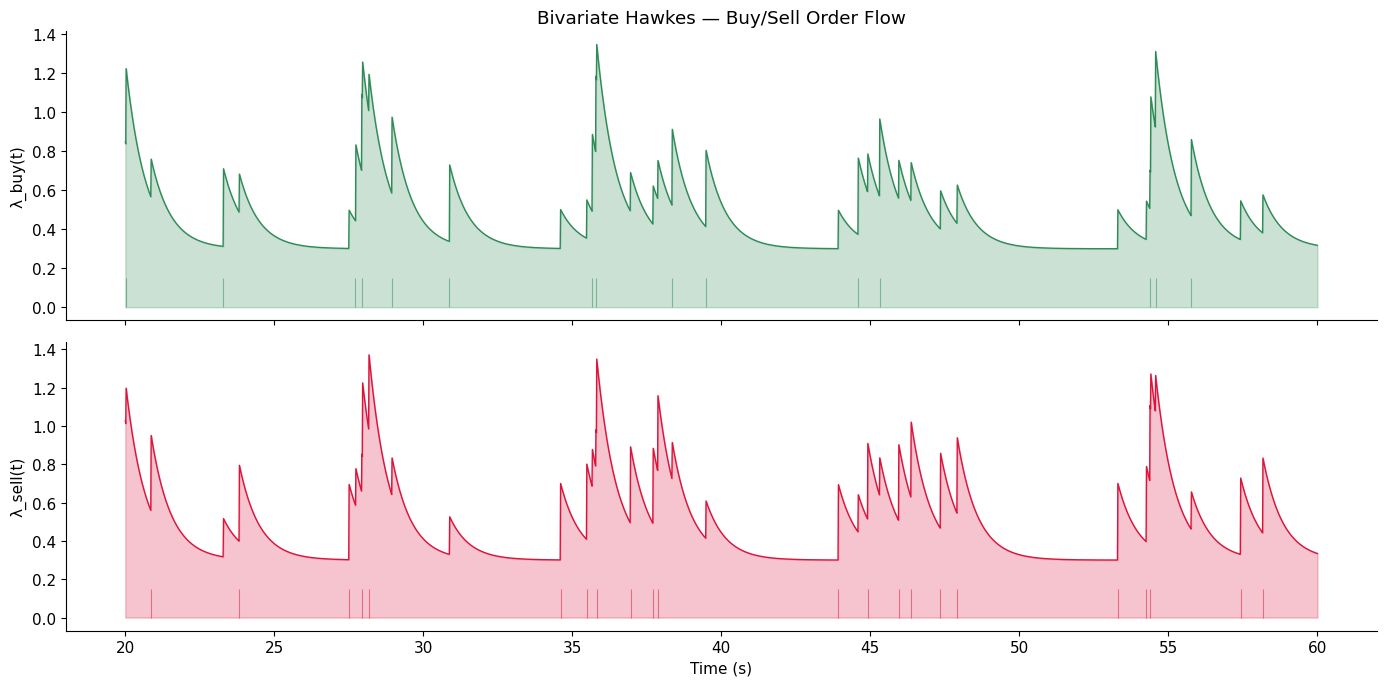

In [ ]:
# Visualize bivariate process
t0_bv, t1_bv = 20, 60
t_grid_bv = np.linspace(t0_bv, t1_bv, 3000)

def intensity_bivariate(events_list, mu, alpha_matrix, beta, t_grid, process_idx):
    """Compute intensity for one process of the bivariate model."""
    lam = np.full_like(t_grid, mu[process_idx])
    for j in range(2):
        for tj in events_list[j]:
            mask = t_grid > tj
            lam[mask] += alpha_matrix[process_idx][j] * np.exp(-beta * (t_grid[mask] - tj))
    return lam

lam_buy = intensity_bivariate([buys, sells], mu_bv, alpha_bv, beta_bv, t_grid_bv, 0)
lam_sell = intensity_bivariate([buys, sells], mu_bv, alpha_bv, beta_bv, t_grid_bv, 1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Buy intensity
ax = axes[0]
ax.fill_between(t_grid_bv, lam_buy, alpha=0.25, color='seagreen')
ax.plot(t_grid_bv, lam_buy, color='seagreen', lw=1)
buy_window = buys[(buys >= t0_bv) & (buys <= t1_bv)]
ax.vlines(buy_window, 0, 0.15, color='seagreen', lw=0.8, alpha=0.5)
ax.set(ylabel='λ_buy(t)', title='Bivariate Hawkes — Buy/Sell Order Flow')

# Sell intensity
ax = axes[1]
ax.fill_between(t_grid_bv, lam_sell, alpha=0.25, color='crimson')
ax.plot(t_grid_bv, lam_sell, color='crimson', lw=1)
sell_window = sells[(sells >= t0_bv) & (sells <= t1_bv)]
ax.vlines(sell_window, 0, 0.15, color='crimson', lw=0.8, alpha=0.5)
ax.set(xlabel='Time (s)', ylabel='λ_sell(t)')

plt.tight_layout()
plt.show()

## 7. Possible next steps to consider

This is a basic very much vibe-coded introduction to play around with things, and here's what can be done with it:

### Data Pipeline
- Pull real trade/order timestamps from Kalshi's API
- Classify events as buys vs sells (trade direction inference)
- Fit the bivariate model to real data and track parameters over time

### Modeling Extensions
- **Non-exponential kernels**: power-law decay captures longer memory in order flow
- **Marked Hawkes**: attach marks (trade size, price impact) to each event
- **Regime-switching baseline**: let $\mu$ vary with time-of-day or news arrival

### Signal Generation
- Use real-time intensity as a **volatility proxy** for dynamic position sizing
- Detect **order flow imbalance** from the bivariate model (λ_buy ≫ λ_sell → bullish)
- Compute branching ratio over rolling windows as a **regime indicator**

### Libraries to Explore
- [`tick`](https://x-datainitiative.github.io/tick/) — fast Hawkes fitting in Python
- [`hawkeslib`](https://github.com/canerturkmen/hawkeslib) — Bayesian Hawkes estimation
- [`pytorch`](https://pytorch.org/) — neural Hawkes processes for flexible kernels

In [ ]:
# Quick reference: parameter summary
print("="*50)
print("  PARAMETER RECOVERY SUMMARY")
print("="*50)
print(f"  {'Param':<12} {'True':>8} {'Estimated':>10}")
print(f"  {'-'*32}")
print(f"  {'μ':<12} {MU:>8.4f} {mu_hat:>10.4f}")
print(f"  {'α':<12} {ALPHA:>8.4f} {alpha_hat:>10.4f}")
print(f"  {'β':<12} {BETA:>8.4f} {beta_hat:>10.4f}")
print(f"  {'α/β':<12} {ALPHA/BETA:>8.4f} {alpha_hat/beta_hat:>10.4f}")
print("="*50)

  PARAMETER RECOVERY SUMMARY
  Param            True  Estimated
  --------------------------------
  μ              0.5000     0.4480
  α              0.8000     0.9967
  β              1.2000     1.2760
  α/β            0.6667     0.7811


In [ ]:
def compute_bivariate_intensity(buys: np.ndarray,
                                 sells: np.ndarray,
                                 mu: np.ndarray,
                                 alpha: np.ndarray,
                                 beta: float,
                                 t_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Compute λ_buy(t) and λ_sell(t) on a time grid.
    Vectorized over t_grid; O(n_events * n_grid) — use a short window.
    """
    mu1, mu2 = mu
    a11, a12 = alpha[0]
    a21, a22 = alpha[1]

    lam_buy  = np.full_like(t_grid, mu1)
    lam_sell = np.full_like(t_grid, mu2)

    for tb in buys:
        mask = t_grid > tb
        decay = np.exp(-beta * (t_grid[mask] - tb))
        lam_buy[mask]  += a11 * decay
        lam_sell[mask] += a21 * decay

    for ts in sells:
        mask = t_grid > ts
        decay = np.exp(-beta * (t_grid[mask] - ts))
        lam_buy[mask]  += a12 * decay
        lam_sell[mask] += a22 * decay

    return lam_buy, lam_sell


# ── 1. Branching matrix heatmap ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
im = ax.imshow(B, cmap='YlOrRd', vmin=0)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{B[i,j]:.3f}', ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_xticklabels(['← Buy', '← Sell'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Buy →', 'Sell →'])
ax.set_title(f'Branching matrix B = α/β\n(ρ = {fit["spectral_radius"]:.3f})', fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.046)

# ── 2. Granger causality bar chart ─────────────────────────────────────────────
ax = axes[1]
labels  = ['Self-excitation\n(buy←buy)', 'Cross-excitation\n(buy←sell)',
           'Cross-excitation\n(sell←buy)', 'Self-excitation\n(sell←sell)']
values  = [B[0,0], B[0,1], B[1,0], B[1,1]]
colors  = ['seagreen', 'mediumpurple', 'mediumpurple', 'crimson']
bars = ax.bar(labels, values, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(0, color='gray', lw=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=10)
ax.set(ylabel='B_ij  (expected triggered events)', title='Excitation structure')
ax.tick_params(axis='x', labelsize=8)

# ── 3. Order-flow imbalance over a window ──────────────────────────────────────
ax = axes[2]
# Use the last min(600, T) seconds so the plot is interpretable
window = min(600.0, T_real)
t0_win = T_real - window
t_grid = np.linspace(t0_win, T_real, 1500)

buys_w  = buys[buys >= t0_win]
sells_w = sells[sells >= t0_win]

lam_b, lam_s = compute_bivariate_intensity(
    buys_w, sells_w, fit['mu'], fit['alpha'], fit['beta'], t_grid
)
total = lam_b + lam_s
ofi   = np.where(total > 0, (lam_b - lam_s) / total, 0.0)

ax.fill_between(t_grid - t0_win, ofi,
                where=(ofi >= 0), color='seagreen', alpha=0.4, label='Buy pressure')
ax.fill_between(t_grid - t0_win, ofi,
                where=(ofi <  0), color='crimson',  alpha=0.4, label='Sell pressure')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set(xlabel=f'Seconds (last {window:.0f}s of data)',
       ylabel='OFI  (λ_buy − λ_sell) / (λ_buy + λ_sell)',
       title='Hawkes Order-Flow Imbalance')
ax.set_ylim(-1, 1)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Print summary ──────────────────────────────────────────────────────────────
print("=== KEY DERIVED RESULTS ===\n")

self_asym = B[0,0] - B[1,1]
cross_asym = B[1,0] - B[0,1]  # sell←buy vs buy←sell

print(f"Self-excitation asymmetry  (B₁₁ - B₂₂) = {self_asym:+.4f}")
if abs(self_asym) < 0.02:
    print("  → Buys and sells are roughly equally self-exciting (symmetric market).")
elif self_asym > 0:
    print("  → Buys are more self-exciting: momentum is stronger on the buy side.")
else:
    print("  → Sells are more self-exciting: momentum is stronger on the sell side.")

print(f"\nGranger causality  (B₂₁ - B₁₂) = {cross_asym:+.4f}")
if abs(cross_asym) < 0.02:
    print("  → Cross-excitation is symmetric — neither side dominates the other.")
elif cross_asym > 0:
    print("  → Buys trigger sells more than vice versa (buy pressure spills into selling).")
else:
    print("  → Sells trigger buys more than vice versa (sell pressure spills into buying).")

print(f"\nSpectral radius ρ(B) = {fit['spectral_radius']:.4f}")
if fit['spectral_radius'] > 0.9:
    print("  ⚠  Near-critical: market is highly reactive; expect large, prolonged bursts.")
elif fit['spectral_radius'] > 0.6:
    print("  ↗  Moderately excited: meaningful clustering, but process is stable.")
else:
    print("  ✓  Low excitation: most events are exogenous (news/background flow).")

mean_ofi = np.mean(ofi)
print(f"\nMean OFI over window = {mean_ofi:+.4f}")
if abs(mean_ofi) < 0.05:
    print("  → Market is roughly balanced over this window.")
elif mean_ofi > 0:
    print("  → Net buying pressure observed in this window.")
else:
    print("  → Net selling pressure observed in this window.")

---
## 11. Derived Results

### What the branching matrix tells us

The **branching matrix** $B_{ij} = \alpha_{ij}/\beta$ is the expected number of type-$i$ events directly triggered by one type-$j$ event. It answers four questions:

| Entry | Question |
|-------|---------|
| $B_{11}$ | How many extra buys does one buy generate? |
| $B_{12}$ | How many buys does one sell generate? |
| $B_{21}$ | How many sells does one buy generate? |
| $B_{22}$ | How many extra sells does one sell generate? |

### Granger causality
In a Hawkes process, process $j$ **Granger-causes** process $i$ iff $\alpha_{ij} > 0$.
Comparing $\alpha_{21}$ vs $\alpha_{12}$ tells you which direction dominates:
- $\alpha_{21} > \alpha_{12}$ → buys trigger sells more than sells trigger buys (buy pressure spills over)
- $\alpha_{12} > \alpha_{21}$ → sell pressure dominates cross-excitation

### Order-flow imbalance signal
$$\text{OFI}(t) = \frac{\lambda_{\text{buy}}(t) - \lambda_{\text{sell}}(t)}{\lambda_{\text{buy}}(t) + \lambda_{\text{sell}}(t)} \in [-1, +1]$$

Positive = net buying pressure in the intensity, negative = net selling pressure.

In [ ]:
from scipy.stats import kstest, expon

def bivariate_compensator(events_self: np.ndarray,
                           events_other: np.ndarray,
                           mu_k: float,
                           a_self: float,
                           a_other: float,
                           beta: float) -> np.ndarray:
    """
    Compute Λ_k(t_i) for each event in events_self using O(n log n) merge.

    a_self  = alpha_{k, same process}
    a_other = alpha_{k, other process}
    """
    n = len(events_self)
    Lambda = np.zeros(n)

    for i, t in enumerate(events_self):
        past_self  = events_self[:i]
        past_other = events_other[events_other < t]

        Lambda[i] = (mu_k * t
                     + (a_self  / beta) * np.sum(1 - np.exp(-beta * (t - past_self)))
                     + (a_other / beta) * np.sum(1 - np.exp(-beta * (t - past_other))))

    return Lambda


def gof_bivariate(fit: dict,
                  buys: np.ndarray,
                  sells: np.ndarray) -> None:
    mu1, mu2 = fit['mu']
    a11, a12 = fit['alpha'][0]
    a21, a22 = fit['alpha'][1]
    beta     = fit['beta']

    Lam_buy  = bivariate_compensator(buys,  sells, mu1, a11, a12, beta)
    Lam_sell = bivariate_compensator(sells, buys,  mu2, a22, a21, beta)

    gaps_buy  = np.diff(Lam_buy)
    gaps_sell = np.diff(Lam_sell)

    ks_buy  = kstest(gaps_buy,  'expon', args=(0, 1))
    ks_sell = kstest(gaps_sell, 'expon', args=(0, 1))

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    for row, (gaps, label, color, ks) in enumerate([
        (gaps_buy,  "Buy",  "seagreen", ks_buy),
        (gaps_sell, "Sell", "crimson",  ks_sell),
    ]):
        # QQ plot
        ax = axes[row, 0]
        emp = np.sort(gaps)
        theo = np.sort(-np.log(1 - np.arange(1, len(gaps)+1) / (len(gaps)+1)))
        mx = max(theo.max(), emp.max())
        ax.scatter(theo, emp, s=6, alpha=0.4, color=color)
        ax.plot([0, mx], [0, mx], 'k--', lw=1)
        ax.set(xlabel='Theoretical Exp(1)',
               ylabel='Empirical',
               title=f'{label} QQ — KS p={ks.pvalue:.3f}')
        verdict = "✓ not rejected" if ks.pvalue > 0.05 else "✗ rejected (p<0.05)"
        ax.text(0.05, 0.92, verdict, transform=ax.transAxes, fontsize=10,
                color='green' if ks.pvalue > 0.05 else 'red')

        # Histogram
        ax = axes[row, 1]
        ax.hist(gaps, bins=40, density=True, alpha=0.6, color=color, edgecolor='white')
        x = np.linspace(0, np.percentile(gaps, 99), 200)
        ax.plot(x, np.exp(-x), 'k-', lw=2, label='Exp(1)')
        ax.set(xlabel='Rescaled gap', ylabel='Density',
               title=f'{label} rescaled intervals')
        ax.legend()

    plt.suptitle('Goodness-of-Fit: Time-Rescaling Theorem (Bivariate Hawkes)', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"Buy  process — KS stat: {ks_buy.statistic:.4f},  p: {ks_buy.pvalue:.4f}  "
          f"{'✓' if ks_buy.pvalue  > 0.05 else '✗'}")
    print(f"Sell process — KS stat: {ks_sell.statistic:.4f},  p: {ks_sell.pvalue:.4f}  "
          f"{'✓' if ks_sell.pvalue > 0.05 else '✗'}")
    print()
    print("Interpretation:")
    print("  p > 0.05 → model is not rejected; the fit is statistically acceptable.")
    print("  p < 0.05 → model is mis-specified (consider power-law kernel or marks).")


print("Running goodness-of-fit diagnostics (may take a moment for large datasets)...")
gof_bivariate(fit, buys, sells)

---
## 10. Goodness-of-Fit — Time Rescaling (Bivariate)

Apply the time-rescaling theorem to each process independently.
For process $k$, the compensator at event time $t_i^{(k)}$ is:

$$\Lambda_k(t_i^{(k)}) = \mu_k t_i^{(k)} + \frac{\alpha_{k1}}{\beta}\sum_{j: t_j^{(1)} < t_i^{(k)}}(1 - e^{-\beta(t_i^{(k)} - t_j^{(1)})}) + \frac{\alpha_{k2}}{\beta}\sum_{j: t_j^{(2)} < t_i^{(k)}}(1 - e^{-\beta(t_i^{(k)} - t_j^{(2)})})$$

If the model is correct, inter-compensator gaps $\Delta\Lambda_k \sim \text{Exp}(1)$.

In [ ]:
from scipy.optimize import minimize
import warnings

def fit_bivariate_hawkes(buys: np.ndarray,
                         sells: np.ndarray,
                         T: float,
                         n_restarts: int = 8,
                         seed: int = 0) -> dict:
    """
    Fit bivariate Hawkes via MLE with multiple random restarts.

    Returns a dict with fitted parameters and diagnostics.
    """
    rng = np.random.default_rng(seed)
    best_result = None
    best_nll    = np.inf

    # Empirical rates as initialization anchor
    rate_buy  = len(buys)  / T
    rate_sell = len(sells) / T

    for i in range(n_restarts):
        # Random starting points sampled around reasonable values
        mu1  = rng.uniform(0.01, rate_buy  * 0.8)
        mu2  = rng.uniform(0.01, rate_sell * 0.8)
        beta = rng.uniform(0.5, 5.0)
        # alpha values: each row sum must be < beta
        a11  = rng.uniform(0.01, beta * 0.4)
        a12  = rng.uniform(0.01, beta * 0.4)
        a21  = rng.uniform(0.01, beta * 0.4)
        a22  = rng.uniform(0.01, beta * 0.4)
        x0   = [mu1, mu2, a11, a12, a21, a22, beta]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            res = minimize(
                bivariate_hawkes_negloglik,
                x0,
                args=(buys, sells, T),
                method='L-BFGS-B',
                bounds=[(1e-6, None)] * 7,
                options={'maxiter': 2000, 'ftol': 1e-12, 'gtol': 1e-8},
            )

        if res.success and res.fun < best_nll:
            best_nll    = res.fun
            best_result = res

    if best_result is None:
        raise RuntimeError("All optimization restarts failed. Try more data or a larger n_restarts.")

    mu1, mu2, a11, a12, a21, a22, beta = best_result.x
    alpha = np.array([[a11, a12], [a21, a22]])

    # Branching matrix B_ij = alpha_ij / beta
    # B_ij = expected number of type-i events triggered by one type-j event
    B = alpha / beta

    # Spectral radius of B (overall self-excitation level; must be < 1)
    eigvals       = np.linalg.eigvals(B)
    spectral_radius = np.max(np.abs(eigvals)).real

    return {
        'mu':             np.array([mu1, mu2]),
        'alpha':          alpha,
        'beta':           beta,
        'branching':      B,
        'spectral_radius': spectral_radius,
        'log_likelihood': -best_nll,
        'n_buy':          len(buys),
        'n_sell':         len(sells),
        'T':              T,
    }


print("Fitting bivariate Hawkes process to real data...")
fit = fit_bivariate_hawkes(buys, sells, T_real, n_restarts=10)

mu1, mu2     = fit['mu']
a11, a12     = fit['alpha'][0]
a21, a22     = fit['alpha'][1]
beta         = fit['beta']
B            = fit['branching']

print("\n=== Bivariate Hawkes MLE ===")
print(f"  μ_buy   = {mu1:.5f} /s   (baseline buy  rate)")
print(f"  μ_sell  = {mu2:.5f} /s   (baseline sell rate)")
print(f"  β       = {beta:.4f}      (decay rate; half-life = {np.log(2)/beta:.3f}s)")
print(f"\n  α matrix (excitation magnitudes):")
print(f"    buy  ← buy   α₁₁ = {a11:.4f}")
print(f"    buy  ← sell  α₁₂ = {a12:.4f}")
print(f"    sell ← buy   α₂₁ = {a21:.4f}")
print(f"    sell ← sell  α₂₂ = {a22:.4f}")
print(f"\n  Branching matrix B = α/β:")
print(f"    B₁₁ = {B[0,0]:.4f}  (buy  ← buy)")
print(f"    B₁₂ = {B[0,1]:.4f}  (buy  ← sell)")
print(f"    B₂₁ = {B[1,0]:.4f}  (sell ← buy)")
print(f"    B₂₂ = {B[1,1]:.4f}  (sell ← sell)")
print(f"\n  Spectral radius ρ(B) = {fit['spectral_radius']:.4f}  {'⚠ near-critical!' if fit['spectral_radius'] > 0.8 else '✓ stable'}")
print(f"  Log-likelihood       = {fit['log_likelihood']:.2f}")

In [ ]:
def bivariate_hawkes_negloglik(params: np.ndarray,
                               buys: np.ndarray,
                               sells: np.ndarray,
                               T: float) -> float:
    """
    Negative log-likelihood for a bivariate exponential Hawkes process
    with shared decay rate β.

    Parameters
    ----------
    params : [mu1, mu2, a11, a12, a21, a22, beta]
        mu1, mu2  — baseline intensities for buys and sells
        a11       — buy self-excitation  (buy  triggered by buy)
        a12       — buy cross-excitation (buy  triggered by sell)
        a21       — sell cross-excitation(sell triggered by buy)
        a22       — sell self-excitation (sell triggered by sell)
        beta      — shared exponential decay rate
    buys, sells : sorted arrays of event times in [0, T]
    T           : observation window length (seconds)

    Returns
    -------
    Negative log-likelihood (scalar, for minimization).
    """
    mu1, mu2, a11, a12, a21, a22, beta = params

    # Hard constraints: positivity and sub-criticality
    if mu1 <= 0 or mu2 <= 0 or beta <= 0:
        return 1e10
    if any(a < 0 for a in [a11, a12, a21, a22]):
        return 1e10
    # Spectral radius of alpha/beta must be < 1 for stationarity.
    # Sufficient condition: row sums < beta.
    if (a11 + a12) >= beta or (a21 + a22) >= beta:
        return 1e10

    # ── Merge both streams into one sorted event list with labels ──────────────
    # label: 0 = buy, 1 = sell
    all_times  = np.concatenate([buys,  sells])
    all_labels = np.concatenate([np.zeros(len(buys), dtype=int),
                                 np.ones(len(sells), dtype=int)])
    order      = np.argsort(all_times, kind='stable')
    all_times  = all_times[order]
    all_labels = all_labels[order]

    # ── Recursive O(n) intensity computation ──────────────────────────────────
    # R[j] = Σ_{past events of type j} exp(-beta * (t_now - t_event))
    # Decays between events, jumps by 1 when its process fires.
    R = np.zeros(2)          # R[0]=buy history sum, R[1]=sell history sum
    ll_buy  = 0.0
    ll_sell = 0.0
    t_prev  = 0.0

    for t, label in zip(all_times, all_labels):
        dt = t - t_prev
        decay = np.exp(-beta * dt)
        R *= decay            # decay both running sums

        # Intensity at this event (before adding the event itself)
        lam_buy  = mu1 + a11 * R[0] + a12 * R[1]
        lam_sell = mu2 + a21 * R[0] + a22 * R[1]

        if label == 0:        # buy event
            if lam_buy <= 0:
                return 1e10
            ll_buy += np.log(lam_buy)
            R[0] += 1.0
        else:                 # sell event
            if lam_sell <= 0:
                return 1e10
            ll_sell += np.log(lam_sell)
            R[1] += 1.0

        t_prev = t

    # ── Compensator: ∫₀ᵀ [λ_buy + λ_sell] ds ─────────────────────────────────
    # ∫₀ᵀ λ_k ds = mu_k * T
    #            + (a_k1/beta) * Σᵢ∈buys  (1 - exp(-beta*(T-tᵢ)))
    #            + (a_k2/beta) * Σⱼ∈sells (1 - exp(-beta*(T-tⱼ)))
    tail_buy  = np.sum(1 - np.exp(-beta * (T - buys)))
    tail_sell = np.sum(1 - np.exp(-beta * (T - sells)))

    comp_buy  = mu1 * T + (a11 / beta) * tail_buy  + (a12 / beta) * tail_sell
    comp_sell = mu2 * T + (a21 / beta) * tail_buy  + (a22 / beta) * tail_sell
    compensator = comp_buy + comp_sell

    ll = ll_buy + ll_sell - compensator
    return -ll   # negate for minimization

---
## 9. Bivariate Hawkes MLE

The bivariate model has **7 parameters** (shared decay rate β):

$$\boldsymbol{\theta} = (\mu_1, \mu_2,\ \alpha_{11}, \alpha_{12}, \alpha_{21}, \alpha_{22},\ \beta)$$

where $\alpha_{ij}$ = excitation of process $i$ by an event in process $j$.

The joint log-likelihood is:

$$\ell(\boldsymbol{\theta}) = \underbrace{\sum_{t_i \in \text{buys}} \log \lambda_1(t_i)}_{\text{buy log-lik}} + \underbrace{\sum_{t_j \in \text{sells}} \log \lambda_2(t_j)}_{\text{sell log-lik}} - \int_0^T [\lambda_1(s) + \lambda_2(s)]\, ds$$

The compensator integral has the closed form:

$$\int_0^T \lambda_k(s)\,ds = \mu_k T + \frac{\alpha_{k1}}{\beta}\sum_{i}(1 - e^{-\beta(T-t_i^{(1)})}) + \frac{\alpha_{k2}}{\beta}\sum_{j}(1 - e^{-\beta(T-t_j^{(2)})})$$

**Recursive O(n) trick**: merge both event streams into one sorted list with labels. Maintain two running sums $R_1(t), R_2(t)$ that decay exponentially between events and jump by 1 when their respective process fires. At each event, compute $\lambda_k$ before incrementing.

In [ ]:
def parse_trades(records: list[dict]) -> tuple[np.ndarray, np.ndarray, float]:
    """
    Convert raw trade records into buy/sell event-time arrays.

    Returns
    -------
    buys   : np.ndarray  — POSIX timestamps of buy (taker_side='yes') trades
    sells  : np.ndarray  — POSIX timestamps of sell (taker_side='no') trades
    T      : float       — total observation window in seconds (t_last - t_first)
    """
    t0 = None
    buys, sells = [], []

    for r in records:
        ts_str = r.get("timestamp", "")
        if not ts_str:
            continue
        try:
            ts = datetime.fromisoformat(ts_str.replace("Z", "+00:00")).timestamp()
        except ValueError:
            continue

        if t0 is None:
            t0 = ts

        # Shift to seconds from first event
        t_rel = ts - t0
        side = r.get("taker_side", "")
        if side == "yes":
            buys.append(t_rel)
        elif side == "no":
            sells.append(t_rel)

    buys  = np.array(sorted(buys))
    sells = np.array(sorted(sells))
    T     = max(buys[-1] if len(buys) else 0,
                sells[-1] if len(sells) else 0)

    return buys, sells, T


buys, sells, T_real = parse_trades(trades_raw)

print(f"Observation window : {T_real:.1f}s  ({T_real/60:.1f} min)")
print(f"Buy  events        : {len(buys)}  ({len(buys)/T_real:.3f} /s)")
print(f"Sell events        : {len(sells)}  ({len(sells)/T_real:.3f} /s)")
print(f"Buy fraction       : {len(buys)/(len(buys)+len(sells))*100:.1f}%")

# Quick inter-arrival sanity plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, times, label, color in [
    (axes[0], buys,  "Buy",  "seagreen"),
    (axes[1], sells, "Sell", "crimson"),
]:
    ia = np.diff(times)
    ax.hist(ia, bins=40, color=color, alpha=0.7, edgecolor='white', density=True)
    ax.set(title=f"{label} inter-arrival distribution",
           xlabel="Seconds between trades", ylabel="Density")
    if len(ia):
        mean_ia = ia.mean()
        x = np.linspace(0, ia.max(), 200)
        ax.plot(x, np.exp(-x / mean_ia) / mean_ia, 'k--', lw=1.5, label=f'Exp({mean_ia:.2f}s)')
        ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import json
import os
from pathlib import Path
from datetime import datetime, timezone
from dotenv import load_dotenv

load_dotenv()

def load_kalshi_trades(data_dir: str = "data", ticker: str | None = None) -> list[dict]:
    """
    Load all trade records from data/{date}/{ticker}_trades.jsonl files.

    Returns a list of dicts sorted by timestamp ascending.
    Raises FileNotFoundError if no trade files are found.
    """
    if ticker is None:
        ticker = os.environ.get("TICKER")
        if not ticker:
            raise ValueError(
                "TICKER is not set. Export it or create a .env file before running this cell.\n"
                "Example:  export TICKER=KXBTC-25APR-T90000"
            )

    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(
            f"Data directory '{data_dir}' does not exist.\n"
            "Run Main.py first to collect trade data."
        )

    records = []
    for date_dir in sorted(data_path.iterdir()):
        if not date_dir.is_dir():
            continue
        trade_file = date_dir / f"{ticker}_trades.jsonl"
        if not trade_file.exists():
            continue
        with trade_file.open() as f:
            for line in f:
                line = line.strip()
                if line:
                    records.append(json.loads(line))

    if not records:
        raise FileNotFoundError(
            f"No trade records found for ticker '{ticker}' under '{data_dir}'.\n"
            "Make sure Main.py has been running and the TICKER env var matches."
        )

    # Sort by timestamp string (ISO format sorts correctly)
    records.sort(key=lambda r: r.get("timestamp", ""))
    return records


trades_raw = load_kalshi_trades()
print(f"Loaded {len(trades_raw)} trades")
print(f"First: {trades_raw[0]['timestamp']}  |  Last: {trades_raw[-1]['timestamp']}")
print(f"Columns: {list(trades_raw[0].keys())}")

---
## 8. Load Real Kalshi Trade Data

Reads from the `data/{date}/{TICKER}_trades.jsonl` files written by `Main.py`.
Each line is a JSON record with `timestamp`, `taker_side` (`yes` = buy, `no` = sell), `yes_price`, and `count`.

The two event streams fed into the bivariate model are:
- **Process 0 (buys)**: all trades where `taker_side == "yes"`
- **Process 1 (sells)**: all trades where `taker_side == "no"`

> **Requires real data.** Run `Main.py` for at least a few minutes first so the `data/` directory is populated.